In [7]:
import shap

In [88]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# Function to generate synthetic data for multi-input multi-output regression


def generate_data(num_samples=1000, num_inputs=5, num_outputs=3):
    """
    Generate synthetic data with `num_inputs` features and `num_outputs` targets.
    :param num_samples: Number of samples to generate.
    :param num_inputs: Number of input features.
    :param num_outputs: Number of output targets.
    :return: Tuple of input and output tensors.
    """
    # Randomly generate input features
    X = np.random.rand(num_samples, num_inputs).astype(np.float32)
    # X[:, 3] = X[:, 0]
    # X[:, 4] = X[:, 0]

    # Create deterministic outputs with specified dependencies
    Y = np.zeros((num_samples, num_outputs), dtype=np.float32)

    Y[:, 0] = 2 * X[:, 0] + 2 * X[:, 1]  # x1out depends on x1 and x2
    Y[:, 1] = 4 * X[:, 1] - 1.5 * X[:, 2]  # x2out depends on x2 and x3
    Y[:, 2] = X[:, 2] + 5 * X[:, 3]  # x3out depends on x3 and x4

    return torch.tensor(X), torch.tensor(Y)


# Define the multi-input, multi-output regression model with three layers


class MultiInputOutputModel(nn.Module):
    def __init__(self, input_size, output_size, hidden_size=64):
        """
        Initialize the model with three fully connected layers.
        :param input_size: Number of input features.
        :param output_size: Number of output targets.
        :param hidden_size: Size of the hidden layers.
        """
        super(MultiInputOutputModel, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        if isinstance(x, np.ndarray):
            x = torch.tensor(x, dtype=torch.float32)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)  # No activation on the final layer for regression
        return x

In [89]:
# Generate data
num_samples = 1000
num_inputs = 5
num_outputs = 3
X, Y = generate_data(num_samples, num_inputs, num_outputs)

In [90]:
# Initialize the model, loss function, and optimizer
model = MultiInputOutputModel(input_size=num_inputs, output_size=num_outputs)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [91]:
# Training loop
num_epochs = 10000
for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X)
    loss = criterion(outputs, Y)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

print("Training complete.")

Epoch [10/10000], Loss: 1.3116
Epoch [20/10000], Loss: 0.6597
Epoch [30/10000], Loss: 0.2521
Epoch [40/10000], Loss: 0.0810
Epoch [50/10000], Loss: 0.0318
Epoch [60/10000], Loss: 0.0185
Epoch [70/10000], Loss: 0.0091
Epoch [80/10000], Loss: 0.0057
Epoch [90/10000], Loss: 0.0045
Epoch [100/10000], Loss: 0.0034
Epoch [110/10000], Loss: 0.0027
Epoch [120/10000], Loss: 0.0023
Epoch [130/10000], Loss: 0.0019
Epoch [140/10000], Loss: 0.0017
Epoch [150/10000], Loss: 0.0015
Epoch [160/10000], Loss: 0.0013
Epoch [170/10000], Loss: 0.0012
Epoch [180/10000], Loss: 0.0011
Epoch [190/10000], Loss: 0.0010
Epoch [200/10000], Loss: 0.0009
Epoch [210/10000], Loss: 0.0008
Epoch [220/10000], Loss: 0.0008
Epoch [230/10000], Loss: 0.0007
Epoch [240/10000], Loss: 0.0007
Epoch [250/10000], Loss: 0.0006
Epoch [260/10000], Loss: 0.0006
Epoch [270/10000], Loss: 0.0006
Epoch [280/10000], Loss: 0.0005
Epoch [290/10000], Loss: 0.0005
Epoch [300/10000], Loss: 0.0005
Epoch [310/10000], Loss: 0.0004
Epoch [320/10000]

X3 = X4 = X0

Y0 = 2 * X0 + 3 * X1   # x1out depends on x1 and x2

Y1 = 4 * X1 - 1.5 * X2 # x2out depends on x2 and x3

Y2 = X2 + 5 * X3      # x3out depends on x3 and x4

In [92]:
background = X[:100]
test_image = X[0:1]

output_index = 0

In [93]:
# Deep Explainer
e_full = shap.DeepExplainer(model, background)
shap_values = e_full.shap_values(background, check_additivity=False)
shap_single_value = e_full.shap_values(test_image, check_additivity=False)
explanation = shap.Explanation(
    shap_values[..., output_index],
    base_values=e_full.expected_value[output_index],
    data=background.numpy(),
    feature_names=[f"Feature {i}" for i in range(num_inputs)],
)
single_explanation = shap.Explanation(
    shap_single_value[..., output_index].squeeze(0),
    base_values=e_full.expected_value[output_index],
    data=test_image.numpy().squeeze(0),
    feature_names=[f"Feature {i}" for i in range(num_inputs)],
)

# Without clustering (using Independent masker)
# masker_no_cluster = shap.maskers.Independent(background.numpy(), max_samples=100)
# e_no_cluster = shap.Explainer(model, masker=masker_no_cluster)
# explanation = e_no_cluster(background.numpy())
# explanation = explanation[..., output_index]
# single_explanation = explanation[0]

# Explainer with mask
# clustering_matrix = np.array([
#     [3, 0, 0.1, 2],    # Cluster X3 and X4
#     [4, 5, 0.1, 3],    # Cluster X0 with the group (X3, X4)
#     [1, 2, 0.6, 2],    # Cluster X1 and X2
#     [6, 7, 0.7, 5]     # Merge all clusters
# ])
# e_full = shap.Explainer(model, masker=shap.maskers.Partition(background.numpy(), max_samples=100, clustering=clustering_matrix))
# e_full = shap.Explainer(model, masker=shap.maskers.Partition(background.numpy(), max_samples=100, clustering='euclidean'))
# explanation = e_full(background.numpy())
# explanation = explanation[..., output_index]
# single_explanation = explanation[0]

In [94]:
# explanation[0]

In [95]:
# shap.initjs()
# shap.plots.force(explanation.base_values, explanation.values[0])

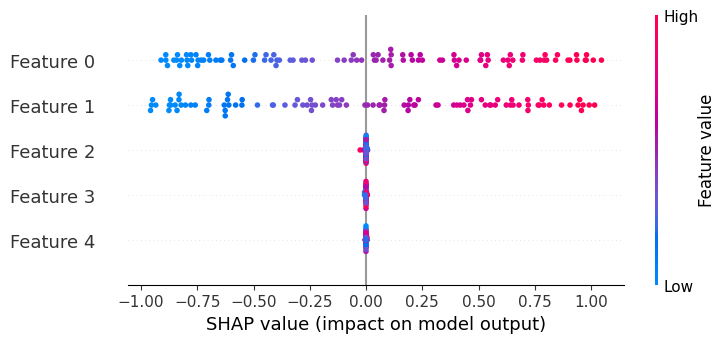

In [96]:
shap.plots.beeswarm(explanation)

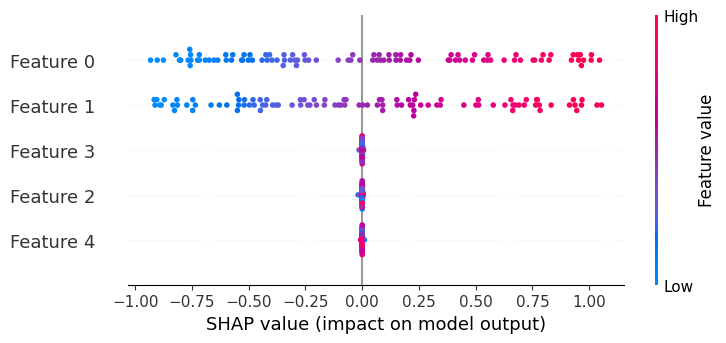

In [78]:
shap.plots.beeswarm(explanation)

In [101]:
Y.mean(axis=0)

tensor([1.9692, 1.2231, 3.0219])

In [97]:
single_explanation.base_values

1.913898777514696

In [103]:
single_explanation.values

array([ 8.02591673e-01,  7.18933532e-01, -8.77195224e-05,  5.10346889e-04,
        2.04282614e-04])

In [98]:
model(torch.tensor(single_explanation.data)).detach().numpy()

array([3.436051 , 2.056749 , 4.3131332], dtype=float32)

In [99]:
single_explanation.values.sum() + single_explanation.base_values

3.4360508918762216

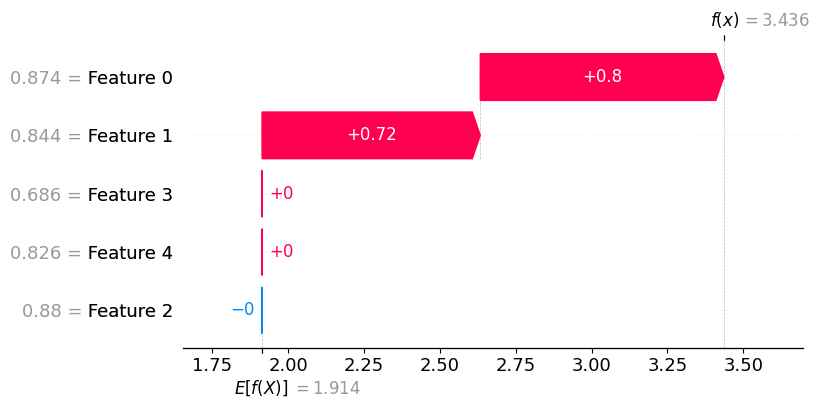

In [100]:
shap.plots.waterfall(single_explanation)

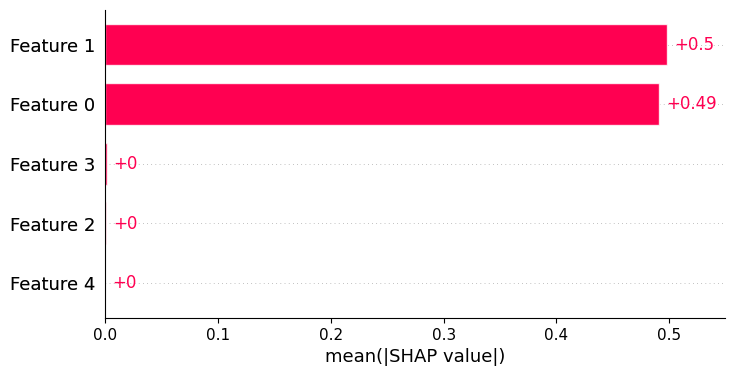

In [64]:
shap.plots.bar(explanation)

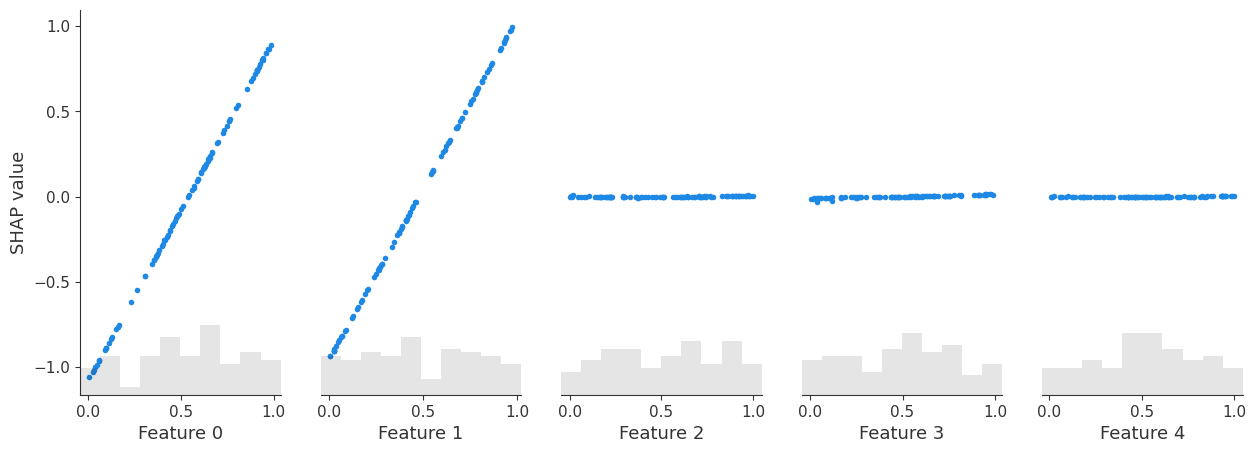

In [30]:
shap.plots.scatter(explanation)

In [20]:
# build a Permutation explainer and explain the model predictions on the given dataset
explainer = shap.explainers.Permutation(model.predict_proba, X)
shap_values = explainer(X[:100])

# get just the explanations for the positive class
shap_values = shap_values[..., 1]

PermutationExplainer explainer: 101it [00:11,  1.53it/s]                         


In [21]:
# build a clustering of the features based on shared information about y
clustering = shap.utils.hclust(X, y)

In [22]:
clustering

array([[ 3.        ,  5.        ,  0.03909243,  2.        ],
       [ 7.        , 12.        ,  0.5777902 ,  3.        ],
       [ 1.        ,  4.        ,  0.60946333,  2.        ],
       [ 2.        , 14.        ,  0.64008868,  3.        ],
       [ 0.        , 13.        ,  0.6534245 ,  4.        ],
       [15.        , 16.        ,  0.82917917,  7.        ],
       [11.        , 17.        ,  0.85433054,  8.        ],
       [10.        , 18.        ,  0.87416214,  9.        ],
       [ 8.        , 19.        ,  0.94810259, 10.        ],
       [ 9.        , 20.        ,  0.970272  , 11.        ],
       [ 6.        , 21.        ,  0.97624069, 12.        ]])

In [23]:
X

,Age,Workclass,Education-Num,Marital Status,Occupation,Relationship,Race,Sex,Capital Gain,Capital Loss,Hours per week,Country
0,39.0,7,13.0,4,1,0,4,1,2174.0,0.0,40.0,39
1,50.0,6,13.0,2,4,4,4,1,0.0,0.0,13.0,39
2,38.0,4,9.0,0,6,0,4,1,0.0,0.0,40.0,39
3,53.0,4,7.0,2,6,4,2,1,0.0,0.0,40.0,39
4,28.0,4,13.0,2,10,5,2,0,0.0,0.0,40.0,5
...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27.0,4,12.0,2,13,5,4,0,0.0,0.0,38.0,39
32557,40.0,4,9.0,2,7,4,4,1,0.0,0.0,40.0,39
32558,58.0,4,9.0,6,1,1,4,0,0.0,0.0,40.0,39
32559,22.0,4,9.0,4,1,3,4,1,0.0,0.0,20.0,39
